In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
df_train = pd.read_csv("/kaggle/input/titanic/train.csv")
df_test = pd.read_csv("/kaggle/input/titanic/test.csv")

In [4]:
df_train.head(10)   # See first 10 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
df_test.tail(10)   # See last 10 rows

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
408,1300,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q
409,1301,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S
410,1302,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
411,1303,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q
412,1304,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [6]:
df_train.info()   # Give informatin about features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df_train.isnull().sum()  # Check null values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df_train.describe()  #statistical informations

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df_train.corr()  # Check colleration with features

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


## EDA

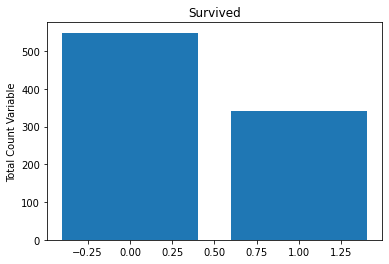

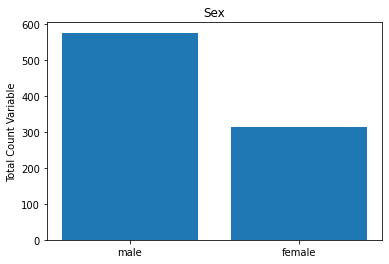

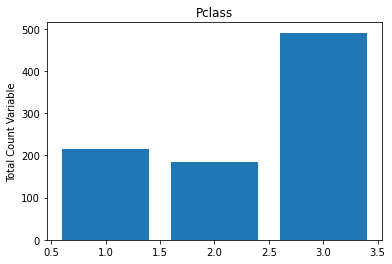

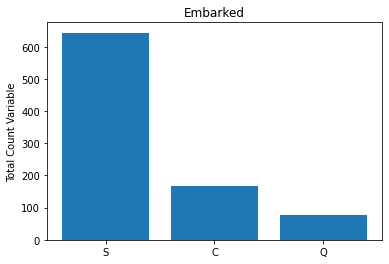

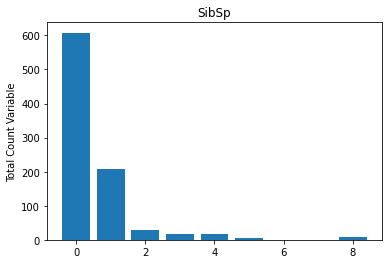

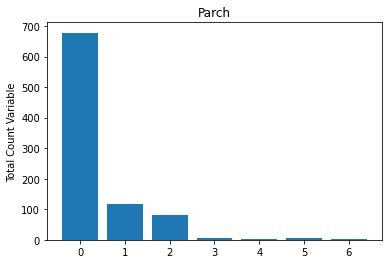

In [10]:
categorical_features = ["Survived","Sex","Pclass","Embarked","SibSp", "Parch"]

for each in categorical_features:
    plt.figure(figsize = (6,4))
    feature = df_train[each]
    count_variable = feature.value_counts()
    plt.bar(count_variable.index, count_variable)
    plt.ylabel("Total Count Variable")
    plt.title(each)
    plt.show()

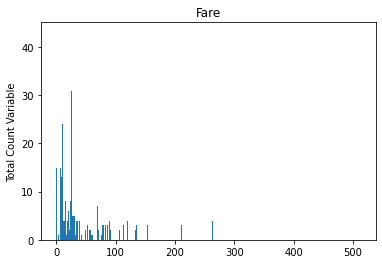

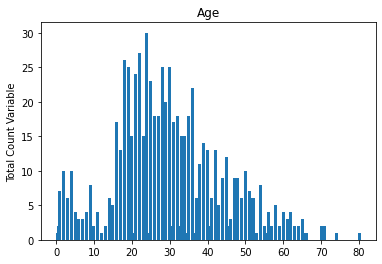

In [11]:
nümerical_features = ["Fare", "Age"]

for each in nümerical_features:
    plt.figure(figsize = (6,4))
    feature = df_train[each]
    count_variable = feature.value_counts()
    plt.bar(count_variable.index, count_variable)
    plt.ylabel("Total Count Variable")
    plt.title(each)
    plt.show()

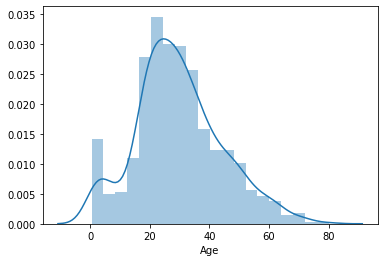

In [12]:
sns.distplot(df_train['Age']);

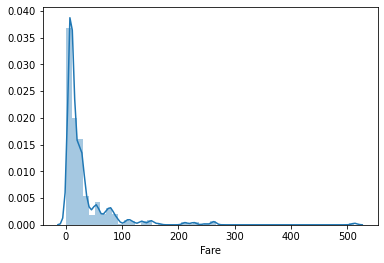

In [13]:
sns.distplot(df_train['Fare']);

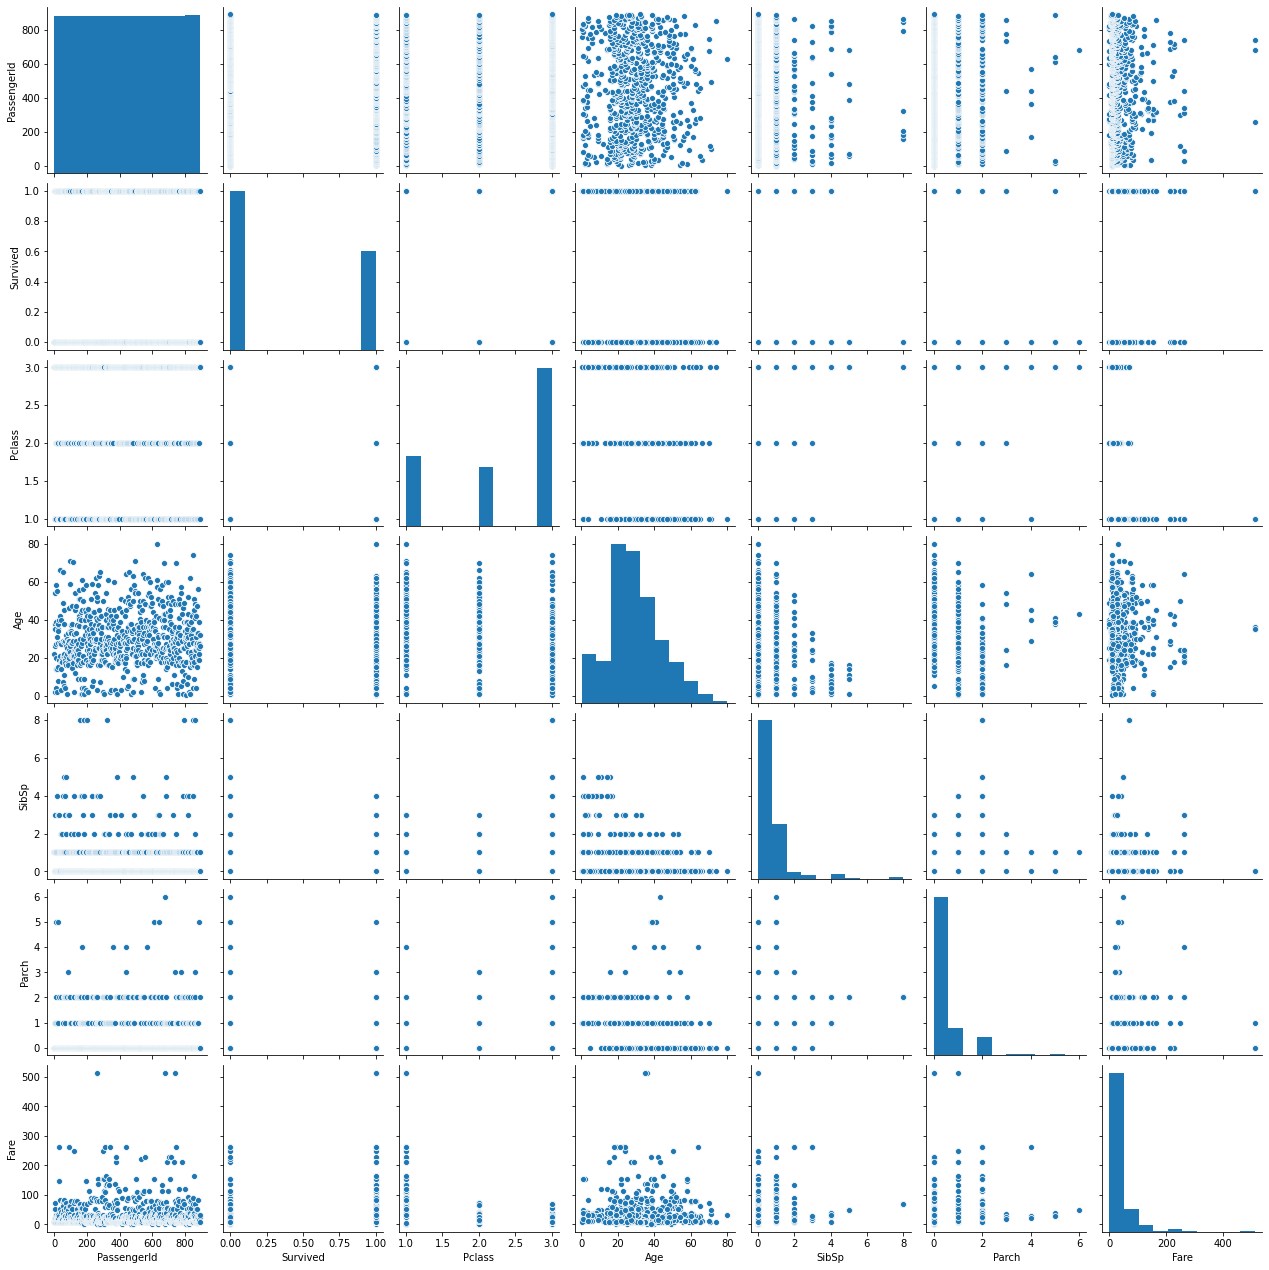

In [14]:
sns.pairplot(df_train)    # See all plots amongst all features

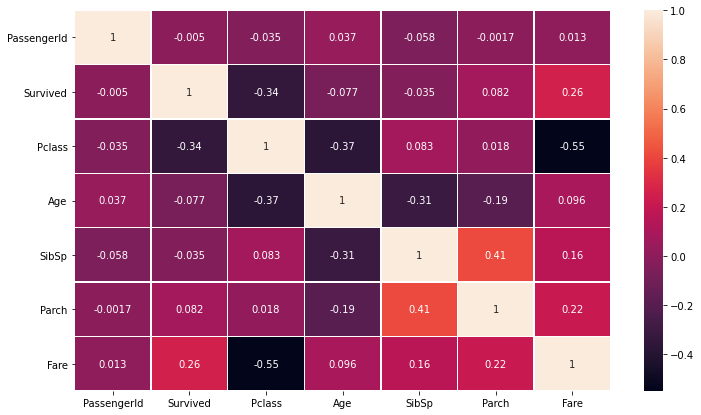

In [15]:
fig, ax = plt.subplots(figsize=(12,7))
sns.heatmap(df_train.corr(), annot=True, linewidths = .5, ax = ax);

### Outliers values are contrary to the distribution in the dataset. Therefore, its detection and removal from the dataset will increase the success rate of the model.

In [16]:
features = ["Age","SibSp","Parch","Fare"]

In [17]:
outlier_indices = []
for each in features:
    Q1 = np.percentile(df_train[each],25)    # 1st quartile
    Q3 = np.percentile(df_train[each],75)   # 3rd quartile
    IQR = Q3 - Q1                           # IQR
    outlier_step = IQR * 1.5                # outlier steps formula
    outlier_list_col = df_train[(df_train[each] < Q1 - outlier_step) | (df_train[each] > Q3 + outlier_step)].index  # detect outlier and their indeces
    outlier_indices.extend(outlier_list_col)

In [18]:
from collections import Counter

outlier_indices = Counter(outlier_indices)
multiple_outliers = list(i for i, v in outlier_indices.items() if v > 2)

In [19]:
multiple_outliers    # These are outliers' indices

[27, 88, 159, 180, 201, 324, 341, 792, 846, 863]

### In order to apply this process to its entire database, we need to convert it to a function.

In [20]:
def detect_outliers(df,features):        # need dataframe and features
    outlier_indices = []
    
    for each in features:
        Q1 = np.percentile(df[each],25)
        Q3 = np.percentile(df[each],75)
        IQR = Q3 - Q1
        outlier_step = IQR * 1.5
        outlier_list_col = df[(df[each] < Q1 - outlier_step) | (df[each] > Q3 + outlier_step)].index
        outlier_indices.extend(outlier_list_col)
    
    outlier_indices = Counter(outlier_indices)
    multiple_outliers = list(i for i, v in outlier_indices.items() if v > 2)
    
    return multiple_outliers

### Apply and check dataset within multiple_outliers

In [21]:
df_train.loc[detect_outliers(df_train,features)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.00,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.00,C23 C25 C27,S
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.00,C23 C25 C27,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


### Removing outliers

In [22]:
df_train = df_train.drop(detect_outliers(df_train,["Age","SibSp","Parch","Fare"]),axis = 0).reset_index(drop = True)
df_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Finding missing value

In [23]:
df_train.isnull().sum()    # Again we should check null values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            170
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          680
Embarked         2
dtype: int64

In [24]:
df_train[df_train["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
60,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
821,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [25]:
df_train["Embarked"] = df_train["Embarked"].fillna("C")   # Fill embarked feature

In [26]:
df_train[df_train["Embarked"].isnull()]   # Again check this feature

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [27]:
df_train[df_train["Age"].isnull()].head(10)    # Check another feature

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
27,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
28,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.8958,NaN,S
30,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
31,33,1,3,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.7500,NaN,Q
35,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.2292,NaN,C
41,43,0,3,"Kraeff, Mr. Theodor",male,NaN,0,0,349253,7.8958,NaN,C


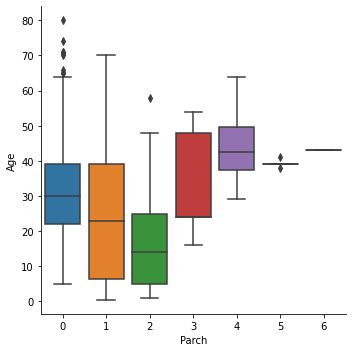

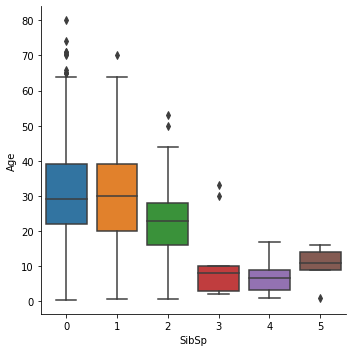

In [28]:
sns.factorplot(x = "Parch", y = "Age", data = df_train, kind = "box")
sns.factorplot(x = "SibSp", y = "Age", data = df_train, kind = "box")
plt.show()

### Fill Age Feature

In [29]:
index_nan_age = list(df_train["Age"][df_train["Age"].isnull()].index)
for i in index_nan_age:
    age_pred = df_train["Age"][((df_train["SibSp"] == df_train.iloc[i]["SibSp"]) &(df_train["Parch"] == df_train.iloc[i]["Parch"])& (df_train["Pclass"] == df_train.iloc[i]["Pclass"]))].median()
    age_med = df_train["Age"].median()
    if not np.isnan(age_pred):
        df_train["Age"].iloc[i] = age_pred
    else:
        df_train["Age"].iloc[i] = age_med

In [30]:
df_train[df_train["Age"].isnull()]   # Check this feature

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


### We prepare another categorical feature to nümerical feature

In [31]:
sex_variable = []
for each in df_train["Sex"]:
    if each == 'male':
        i = 1
        sex_variable.append(i)
    else:
        i = 0
        sex_variable.append(i)
        
df_train["Sex"] = sex_variable    

 ### Feature Analysis and Corralation between two feature to Understand dataset

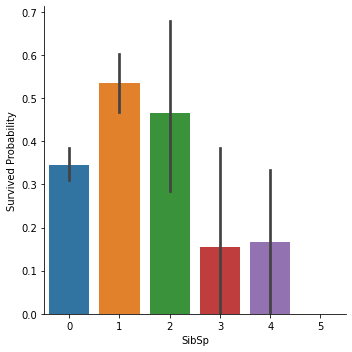

In [32]:
g = sns.factorplot(x = "SibSp", y = "Survived", data = df_train, kind = "bar", size = 5)
g.set_ylabels("Survived Probability")
plt.show()

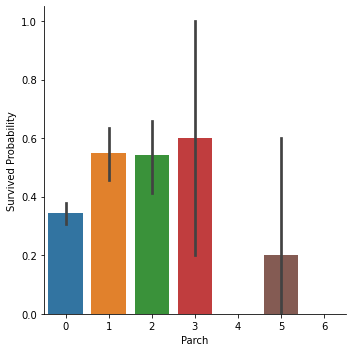

In [33]:
g = sns.factorplot(x = "Parch", y = "Survived", kind = "bar", data = df_train, size = 5)
g.set_ylabels("Survived Probability")
plt.show()

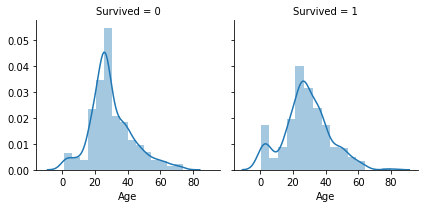

In [34]:
g = sns.FacetGrid(df_train, col = "Survived")
g.map(sns.distplot, "Age", bins = 15)
plt.show()

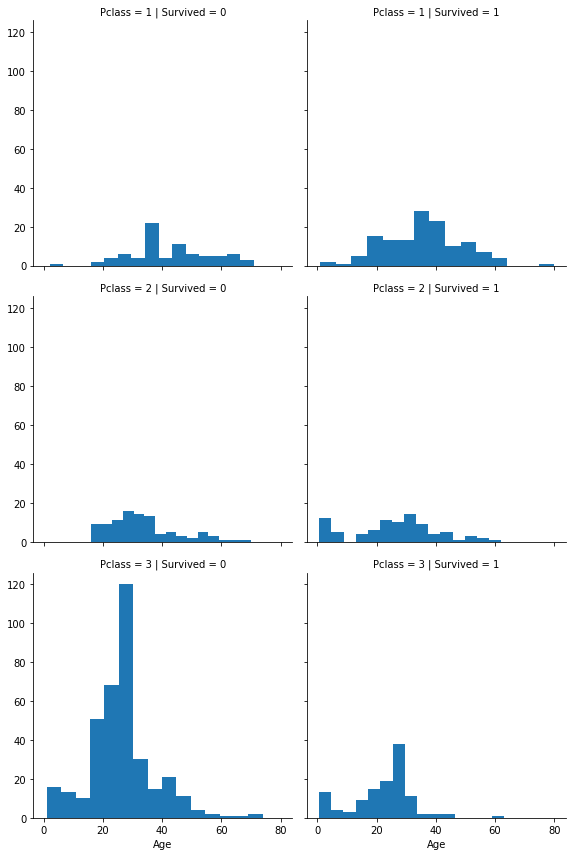

In [35]:
g = sns.FacetGrid(df_train, col = "Survived", row = "Pclass", size = 4)
g.map(plt.hist, "Age", bins = 15)
g.add_legend()
plt.show()

### Feature Engineering / Get Dummies

#####  Categorical features --> Nümerical Features to prepare models

In [36]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [37]:
name = df_train["Name"]

pdlist = []

for i in name:
    name_change = i.split(".")[0].split(",")[-1].strip()
    pdlist.append(name_change)
    
df_train["Title"] = pdlist

In [38]:
df_train["Title"] = df_train["Title"].replace(["Lady","the Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"],"other")

title_variables = []

for i in df_train["Title"]:
    if i == "Master":
        i = 0
    elif i == "Miss" or i == "Ms" or i == "Mlle" or i == "Mrs":
        i == 1
    
    elif i == "Mr":
        i == 2 
    
    else:
        i == 3
        
df_train["Title"] = title_variables

ValueError: Length of values does not match length of index

In [39]:
df_train["Fsize"] = df_train["SibSp"] + df_train["Parch"] + 1

for i in df_train["Fsize"]:
    if i < 5:
        i = 1
    else:
        i = 0

In [40]:
sns.countplot(x = "family_size", data = df_train)
plt.show()

ValueError: Could not interpret input 'family_size'

In [41]:
df_train.head(10)   # Check dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Fsize
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,Mr,1
5,6,0,3,"Moran, Mr. James",1,26.0,0,0,330877,8.4583,NaN,Q,Mr,1
6,7,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.8625,E46,S,Mr,1
7,8,0,3,"Palsson, Master. Gosta Leonard",1,2.0,3,1,349909,21.0750,NaN,S,Master,5
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,27.0,0,2,347742,11.1333,NaN,S,Mrs,3
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",0,14.0,1,0,237736,30.0708,NaN,C,Mrs,2


In [42]:
df_train = pd.get_dummies(df_train, columns= ["family_size"])
df_train.head()

KeyError: "None of [Index(['family_size'], dtype='object')] are in the [columns]"

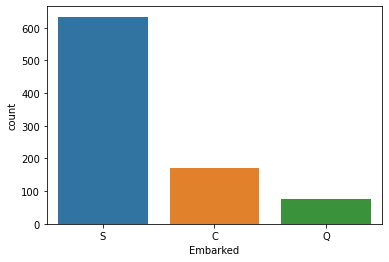

In [43]:
sns.countplot(x = "Embarked", data = df_train)
plt.show()

In [44]:
df_train = pd.get_dummies(df_train, columns=["Embarked"])
df_train.head(10)  # Check dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Title,Fsize,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,Mr,2,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,Mrs,2,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,Miss,1,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,Mrs,2,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,Mr,1,0,0,1
5,6,0,3,"Moran, Mr. James",1,26.0,0,0,330877,8.4583,NaN,Mr,1,0,1,0
6,7,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.8625,E46,Mr,1,0,0,1
7,8,0,3,"Palsson, Master. Gosta Leonard",1,2.0,3,1,349909,21.0750,NaN,Master,5,0,0,1
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,27.0,0,2,347742,11.1333,NaN,Mrs,3,0,0,1
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",0,14.0,1,0,237736,30.0708,NaN,Mrs,2,1,0,0


In [45]:
tickets = []
for i in list(df_train.Ticket):
    if not i.isdigit():
        tickets.append(i.replace(".","").replace("/","").strip().split(" ")[0])
    else:
        tickets.append("x")
        
df_train["Ticket"] = tickets

In [46]:
df_train = pd.get_dummies(df_train, columns= ["Ticket"], prefix = "T")
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,...,T_SOPP,T_SOTONO2,T_SOTONOQ,T_SP,T_STONO,T_STONO2,T_SWPP,T_WC,T_WEP,T_x
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,NaN,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,C85,...,0,0,0,0,0,0,0,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,NaN,...,0,0,0,0,0,1,0,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,C123,...,0,0,0,0,0,0,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,NaN,...,0,0,0,0,0,0,0,0,0,1


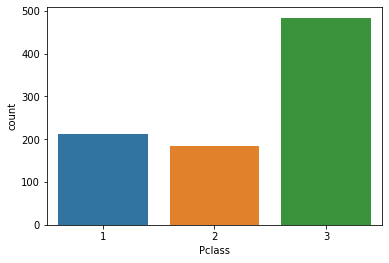

In [47]:
sns.countplot(x = "Pclass", data = df_train)
plt.show()

In [48]:
df_train["Pclass"] = df_train["Pclass"].astype("category")
df_train = pd.get_dummies(df_train, columns= ["Pclass"])

df_train["Sex"] = df_train["Sex"].astype("category")
df_train = pd.get_dummies(df_train, columns=["Sex"])

In [49]:
df_train.drop(labels = ["PassengerId", "Cabin"], axis = 1, inplace = True)

In [50]:
df_train.head(10)

,Survived,Name,Age,SibSp,Parch,Fare,Title,Fsize,Embarked_C,Embarked_Q,...,T_STONO2,T_SWPP,T_WC,T_WEP,T_x,Pclass_1,Pclass_2,Pclass_3,Sex_0,Sex_1
0,0,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,Mr,2,0,0,...,0,0,0,0,0,0,0,1,0,1
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,Mrs,2,1,0,...,0,0,0,0,0,1,0,0,1,0
2,1,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,Miss,1,0,0,...,1,0,0,0,0,0,0,1,1,0
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,Mrs,2,0,0,...,0,0,0,0,1,1,0,0,1,0
4,0,"Allen, Mr. William Henry",35.0,0,0,8.0500,Mr,1,0,0,...,0,0,0,0,1,0,0,1,0,1
5,0,"Moran, Mr. James",26.0,0,0,8.4583,Mr,1,0,1,...,0,0,0,0,1,0,0,1,0,1
6,0,"McCarthy, Mr. Timothy J",54.0,0,0,51.8625,Mr,1,0,0,...,0,0,0,0,1,1,0,0,0,1
7,0,"Palsson, Master. Gosta Leonard",2.0,3,1,21.0750,Master,5,0,0,...,0,0,0,0,1,0,0,1,0,1
8,1,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0,0,2,11.1333,Mrs,3,0,0,...,0,0,0,0,1,0,0,1,1,0
9,1,"Nasser, Mrs. Nicholas (Adele Achem)",14.0,1,0,30.0708,Mrs,2,1,0,...,0,0,0,0,1,0,1,0,1,0


### Train - Test Split

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_train.drop('Survived',axis=1), 
                                                    df_train['Survived'], test_size=0.30, 
                                                    random_state=42)

In [53]:
print("X_train",len(X_train))
print("X_test",len(X_test))
print("y_train",len(y_train))
print("y_test",len(y_test))

X_train 616
X_test 265
y_train 616
y_test 265


### Logistic Regression with SKLearn

In [54]:
from sklearn.linear_model import LogisticRegression
LR  = LogisticRegression()
LR.fit(X_train, y_train)

print("Train Datasets Accuracy: {}".format(LR.score(X_train, y_train)))
print("Test Datasets Accuracy: {}".format(LR.score(X_test, y_test)))

ValueError: could not convert string to float: 'Mr'

### Random Forest

In [55]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier(n_estimators = 300,max_depth = 5,min_samples_split = 3)
RFC.fit(X_train,y_train)

print("Train Datasets Accuracy: {}".format(RFC.score(X_train,y_train)))
print("Test Datasets Accuracy: {}".format(RFC.score(X_test,y_test)))

ValueError: could not convert string to float: 'Chaffee, Mr. Herbert Fuller'

In [56]:
RFC = RandomForestClassifier(n_estimators = 300 ,max_depth = 5, min_samples_split = 10)
RFC.fit(X_train,y_train)

print("Train Datasets Accuracy: {}".format(RFC.score(X_train,y_train)))
print("Test Datasets Accuracy: {}".format(RFC.score(X_test,y_test)))

ValueError: could not convert string to float: 'Chaffee, Mr. Herbert Fuller'

In [57]:
RFC = RandomForestClassifier(n_estimators = 500 ,max_depth = 10 , min_samples_split = 6)
RFC.fit(X_train,y_train)

print("Train Datasets Accuracy: {}".format(RFC.score(X_train,y_train)))
print("Test Datasets Accuracy: {}".format(RFC.score(X_test,y_test)))

ValueError: could not convert string to float: 'Chaffee, Mr. Herbert Fuller'

### KNN

In [58]:
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 30  # as an example

knn = KNeighborsClassifier(n_neighbors = n_neighbors) # n_neighbors = k

knn.fit(X_train,y_train)

prediction = knn.predict(X_test)
print(" {} nn score: {} ".format(n_neighbors, knn.score(X_test,y_test)))

ValueError: could not convert string to float: 'Chaffee, Mr. Herbert Fuller'

In [59]:
score_list = []

for each in range(10,40):
    knn2 = KNeighborsClassifier(n_neighbors = each)
    knn2.fit(X_train,y_train)
    score_list.append(knn2.score(X_test,y_test))
    
plt.plot(range(10,40),score_list)
plt.xlabel("k values")
plt.ylabel("accuracy")
plt.show()

ValueError: could not convert string to float: 'Chaffee, Mr. Herbert Fuller'

### Decision Tree

In [60]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

print("accuracy of decision tree: ", dt.score(X_test,y_test))

ValueError: could not convert string to float: 'Chaffee, Mr. Herbert Fuller'

### LGBM

In [61]:
from lightgbm import LGBMClassifier

LGB = LGBMClassifier(learning_rate = 0.01,max_depth = 5, num_leaves = 3)
LGB.fit(X_train,y_train)

print("Train Datasets Accuracy: {}".format(LGB.score(X_train,y_train)))
print("Test Datasets Accuracy: {}".format(LGB.score(X_test,y_test)))

ValueError: DataFrame.dtypes for data must be int, float or bool.
Did not expect the data types in the following fields: Name, Title